# Ejercicio 1: Scikit-learn (Perceptrón Multicapa)

###	Tarea: Construye un modelo de Perceptrón Multicapa (MLP) utilizando la clase MLPClassifier de Scikit-learn para clasificar las imágenes del dataset MNIST.

## 1. Importación de librerías

Primero importamos las librerías necesarias para trabajar con el dataset MNIST y construir el modelo de Perceptrón Multicapa (MLP).

Utilizaremos:

- `sklearn` para el modelo de clasificación.
- `numpy` para operaciones numéricas.
- `matplotlib` para visualizar datos.
- `confusion_matrix` y `accuracy_score` para evaluar el modelo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Carga del dataset MNIST

Cargamos el dataset MNIST utilizando `fetch_openml`.

Este dataset contiene:
- 70.000 imágenes de dígitos escritos a mano
- Cada imagen tiene tamaño **28x28 píxeles**
- Cada píxel tiene un valor entre **0 y 255**

In [2]:
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.to_numpy()
y = mnist.target.astype(int)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("Tamaño de cada imagen:", X.shape[1])

print("Valor mínimo de los píxeles:", X.min())
print("Valor máximo de los píxeles:", X.max())

Forma de X: (70000, 784)
Forma de y: (70000,)
Tamaño de cada imagen: 784
Valor mínimo de los píxeles: 0
Valor máximo de los píxeles: 255


## 3. Preprocesamiento de los datos 

En imagenes en 8 bits como las de MNIST, cada pixel puede tomar un valor entre 0 y 255, donde 0 representa el color negro y 255 representa el color blanco. Al normalizar los datos, convertimos estos valores a un rango entre 0 y 1, lo que facilita el entrenamiento de la red neuronal.

In [3]:
X = X / X.max().astype(np.float32)

## 4. División del dataset

Usamos train_test_split para dividir 20% test y 80% train

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (56000, 784)
Datos de prueba: (14000, 784)


## 5. Construcción y entrenamiento del modelo MLP

Creamos un modelo de **Perceptrón Multicapa (MLP)** utilizando `MLPClassifier`.

Configuración inicial del modelo:

- Capas ocultas: `(128, 64)` 
- Función de activación: `relu`
- Optimizador: `adam`
- Número máximo de iteraciones: `20`

Esto significa:

Primera capa de entrada: 784 neuronas - píxeles, sin pesos propios  
Primera capa oculta: 128 neuronas - se transforman las 784 features en 128 representaciones más abstractas, con pesos y bias  
Capa de activación: ReLu, pone valores negativos en 0 y positivos los mantiene igual.  
Segunda capa oculta: 64 neuronas – sobre la salida anterior, se hace lo mismo que antes.  
Capa de salida: 10 neuronas – porque tiene 10 clases (números del 0 al 9)  

Utiliza ‘adam’ como optimizador: estándar que converge rápido y funciona bien sin mucho tuning  
Utiliza 20 como parámetro de max_iter, que son las epoch.  
Y random_state en 42 que es estándar para fijar la inicializacion aleatoria y consistencia de resultados para hacer el entrenamiento reproducible sin depender de aleatoriedad.  

784 entradas → 128 neuronas → 64 neuronas → 10 salidas (dígitos 0-9)  
Pixeles → bordes → formas → patrones → dígitos  

(Luego muestro como entreno el modelo con diferentes configuraciones de hiperparámetros y hago sus predicciones en un bucle)


In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=20,
    random_state=42
)

mlp.fit(X_train, y_train)

/home/eze/IA-BigData/venv_iabd/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",20
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## 6. Predicción

Usamos el modelo entrenado para predecir las etiquetas del conjunto de test.

In [8]:
y_pred = mlp.predict(X_test)

## 7. Evaluación del modelo

Evaluamos el rendimiento del modelo utilizando la métrica **Accuracy**: el porcentaje de predicciones correctas sobre el conjunto de test.

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 0.9724285714285714


## 8. Matriz de confusión

La matriz de confusión muestra qué dígitos se clasifican correctamente y cuáles se confunden entre sí.

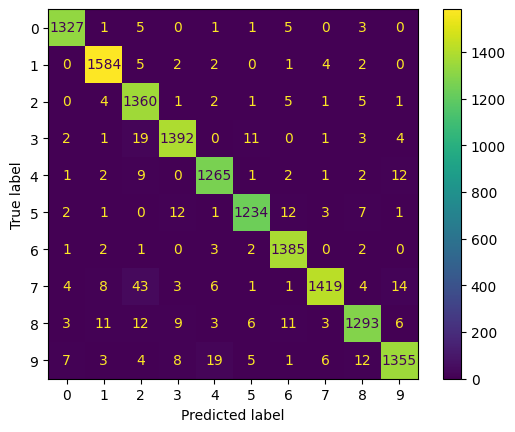

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

## 9. Prueba con diferentes hiperparámetros

Para analizar cómo afectan los hiperparámetros al rendimiento, probamos diferentes configuraciones de capas ocultas manteniendo el resto de parámetros constantes.

In [12]:
configuraciones = [
    (50,),
    (100,),
    (128,64),
    (256,128)
]

for config in configuraciones:
    
    modelo = MLPClassifier(
        hidden_layer_sizes=config,
        activation='relu',
        solver='adam',
        max_iter=20,
        random_state=42
    )
    
    modelo.fit(X_train, y_train)
    
    pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    
    print(f"Capas ocultas {config} -> Accuracy: {acc}")

Capas ocultas (50,) -> Accuracy: 0.9688571428571429
Capas ocultas (100,) -> Accuracy: 0.9746428571428571
Capas ocultas (128, 64) -> Accuracy: 0.9724285714285714
Capas ocultas (256, 128) -> Accuracy: 0.9795714285714285


## Resultados

Podemos observar que:

- La arquitectura `(128, 64)` obtiene un **97.24 %**, ligeramente inferior a una sola capa de 100 neuronas (97.46 %). Añadir profundidad no garantiza mejora si el número total de neuronas es menor.
- La mejor configuración es `(256, 128)` con un **97.96 %**, lo que sugiere que un mayor número total de neuronas permite aprender representaciones más ricas.
- En conjunto, todas las configuraciones se mantienen entre el 96.9 % y el 97.9 %, lo que apunta a un techo de rendimiento del MLP en esta tarea. En los Ejercicios 2 y 3 veremos cómo las CNN superan este límite al aprovechar la estructura espacial de las imágenes.

## Conclusiones

El MLP de Scikit-learn clasifica MNIST con ~97.2–97.9% de accuracy según la arquitectura. Su ventaja es la simplicidad: apenas unos parámetros para definir el modelo y `fit()` para entrenarlo. Su limitación estructural es tratar cada píxel como una característica independiente (vector de 784 valores), ignorando completamente la estructura espacial de la imagen: bordes, curvas y formas no son explotados como tales.

La comparación de arquitecturas (Sección 9) confirma rendimientos decrecientes al añadir capas: el techo práctico del MLP en MNIST ronda el 97.9%, un límite que las CNN de los ejercicios siguientes superarán ampliamente al explotar la localidad espacial de los píxeles.